# Figure 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
from tqdm import tqdm

# Disable chained assignments
pd.options.mode.chained_assignment = None 

# Set colour palette:
pal = sns.diverging_palette(250, 13, s=100, l=35, sep=10, center='light', as_cmap=True)


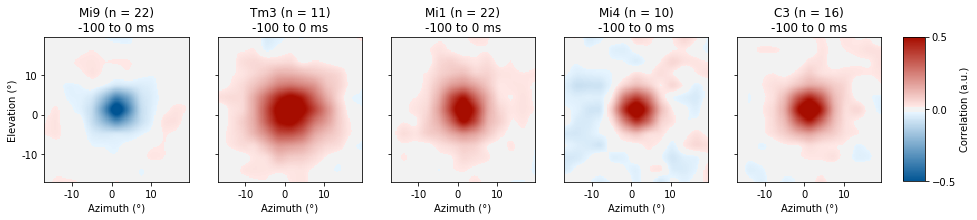

In [7]:
# Figure 1d:
# Load receptive field data:
RFs = np.load('fig1d_receptive_fields.npy', allow_pickle=True, encoding='latin1')[()]

# Define central pixel (for array of shape 13x13):
centre = 6

# Define pixel width:
pw = 180/64 # pixel width = 180°/64 pixels

# Generate a purely spatial receptive field by averaging over time:
def time_avg(rf, tmin, tmax): 
    avg_rf = rf[:,:,180+tmin:180+tmax].mean(2)
    return avg_rf

# Define time frame for averaging:
tmin = -6 # (x 16.667 ms for 60-Hz noise)
tmax = 0

# Average receptive fields over cells and time: 
RF_Mi9 = time_avg(RFs['Mi9'].mean(3), tmin, tmax)
RF_Tm3 = time_avg(RFs['Tm3'].mean(3), tmin, tmax)
RF_Mi1 = time_avg(RFs['Mi1'].mean(3), tmin, tmax)
RF_Mi4 = time_avg(RFs['Mi4'].mean(3), tmin, tmax)
RF_C3 = time_avg(RFs['C3'].mean(3), tmin, tmax)

# Scale colourmap:
vmin = -0.5
vmax = 0.5

# Create figure:
fig, ax = plt.subplots(1, 5, figsize=(15, 3), sharey=True, sharex=True)

names = ['Mi9', 'Tm3', 'Mi1', 'Mi4', 'C3']
data = [RF_Mi9, RF_Tm3, RF_Mi1, RF_Mi4, RF_C3]

# Sample sizes (i.e. cell numbers):
numbers = [RFs['Mi9'].shape[3], RFs['Tm3'].shape[3], RFs['Mi1'].shape[3],
           RFs['Mi4'].shape[3], RFs['C3'].shape[3]]

#smooth = False
smooth = True

if smooth:
    factor = 10
    sigma = 1.8
else:
    factor = 1
    sigma = 0

for idx, d in enumerate(data):
    x = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0])
    y = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1])
    x2 = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0]*factor)
    y2 = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1]*factor)
    f = interp2d(x, y, d, kind='linear')
    d2 = f(x2, y2)
    d = gaussian_filter(d2, sigma=sigma)
    img = ax[idx].imshow(d, vmin=vmin, vmax=vmax, cmap=pal, origin='lower')

ax[0].set_ylabel('Elevation (°)')
for i in range(5):
    ax[i].set_xlabel('Azimuth (°)')
    ax[i].set_title('{0} (n = {1})\n{2} to {3} ms'.format(names[i], numbers[i], int(tmin*(50/3)), int(tmax*(50/3))))
    ax[i].set_yticks([centre*factor - 10/pw*factor, centre*factor,
                      centre*factor + 10/pw*factor]) 
    ax[i].set_xticks([centre*factor - 10/pw*factor, centre*factor,
                      centre*factor + 10/pw*factor])
    ax[i].set_yticklabels([-10, 0, 10])
    ax[i].set_xticklabels([-10, 0, 10])

cbar_ax = fig.add_axes([0.92, 0.17, 0.02, 0.67])
cb = fig.colorbar(img, cax=cbar_ax)
cb.set_label("Correlation (a.u.)")
cb.set_ticks([-0.5, 0, 0.5])
#plt.savefig('fig1d.pdf', dpi=120);

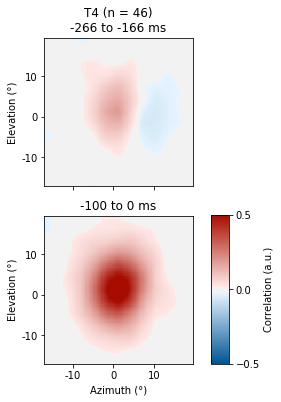

In [6]:
# Figure 1e left: 
pal = sns.diverging_palette(250, 13, s=100, l=35, sep=10, center='light', as_cmap=True)
# Load receptive field data and average over cells:
RF_T4 = np.load('fig1e_receptive_fields.npy').mean(3)

# Sample size (i.e. cell number):
n_T4 = np.load('fig1e_receptive_fields.npy').shape[3]

# Define central pixel (for 17x17 array):
centre = 8

# Define pixel width:
pw = 180/64 # pixel width = 180°/64 pixels

# Generate a spatiotemporal receptive field by averaging over space along elevation:
def get_st_RF(rf, centre):
    st_RF = rf[centre-1:centre+2,:,120:190].mean(0).T
    return st_RF

st_RF_T4 = get_st_RF(rf=RF_T4, centre=centre)

# Generate a purely spatial receptive field by averaging over time:
def time_avg(rf, tmin, tmax): 
    avg_rf = rf[:,:,180+tmin:180+tmax].mean(2)
    return avg_rf

# Extract spatial RFs at different timepoints
# and crop to the same size as data in Fig. 1d:
RF_T4_p = time_avg(RF_T4, -6, 0)[2:-2, 2:-2] # at the peak
RF_T4_t = time_avg(RF_T4, -16, -10)[2:-2, 2:-2] # at the tail

centre = 6                 # redefine centre accordingly

# Spatial receptive fields (left):

# Scale colourmap:
vmin = -0.5
vmax = 0.5

smooth = True
#smooth = False

names = ['tail', 'peak']

# Create figure:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharey=True, sharex=True)

for idx, d in enumerate([RF_T4_t, RF_T4_p]):
    if smooth:
        factor = 10
        sigma = 1.8
    else:
        factor = 1
        sigma = 0
    x = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0])
    y = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1])
    x2 = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0]*factor)
    y2 = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1]*factor)
    f = interp2d(x, y, d, kind='linear')
    d2 = f(x2, y2)
    d = gaussian_filter(d2, sigma=sigma)
    img = ax[idx].imshow(d, vmin=vmin, vmax=vmax, cmap=pal, origin='lower')

    ax[idx].set_ylabel('Elevation (°)')
    ax[idx].set_yticks([centre*factor - 10/pw*factor, centre*factor,
                      centre*factor + 10/pw*factor])
    ax[idx].set_yticklabels([-10, 0, 10])
ax[1].set_xlabel('Azimuth (°)')
ax[0].set_title('T4 (n = {0})\n{1} to {2} ms'.format(n_T4, int(-16*(50/3)), int(-10*(50/3))))
ax[1].set_title('{1} to {2} ms'.format(n_T4, int(-6*(50/3)), int(0*(50/3))))
ax[1].set_xticks([centre*factor - 10/pw*factor, centre*factor,
                      centre*factor + 10/pw*factor])
ax[1].set_xticklabels([-10, 0, 10])

cbar_ax = fig.add_axes([0.62, 0.125, 0.02, 0.345])
cb = fig.colorbar(img, cax=cbar_ax)
cb.set_label("Correlation (a.u.)")
cb.set_ticks([-0.5, 0, 0.5]);

#plt.savefig('fig1e_left.pdf', dpi=120);

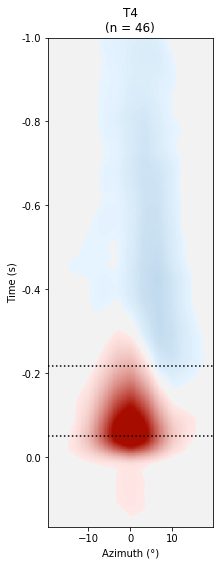

In [11]:
# Figure 1e (spatiotemporal receptive field, right):
fig, ax = plt.subplots(1,1,figsize=(6, 9))

if smooth:
    factor = 10
    sigma = 1.8
else:
    factor = 1
    sigma = 0
d = st_RF_T4[:,2:-2] # crop to the same size as data in Fig. 1d:
x = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1])
y = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0])
x2 = np.linspace(-d.shape[1]/2*pw, d.shape[1]/2*pw, d.shape[1]*factor)
y2 = np.linspace(-d.shape[0]/2*pw, d.shape[0]/2*pw, d.shape[0]*factor)
f = interp2d(x, y, d, kind='linear')
d2 = f(x2, y2)
img = ax.imshow(gaussian_filter(d2, sigma=sigma), vmin=vmin, vmax=vmax, cmap=pal, origin='upper',
                         extent=[-7*pw,7*pw,50/3,-60*(50/3)/10])

ax.set_title('T4\n(n = {})'.format(n_T4))
ax.set_xlabel('Azimuth (°)')
ax.set_yticks([-100, -80, -60, -40, -20, 0])
ax.set_yticklabels([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0])
ax.set_ylabel('Time (s)')
ax.axhline(-5, color='k', linestyle=':')
ax.axhline(-21.6, color='k', linestyle=':');
#plt.savefig('fig1e_right.pdf', dpi=120);

In [12]:
# Figure 1 f–g:
# Import data:
print("Reading data file...")
data = pd.read_csv('fig1fg_grating.csv', index_col=None)
data.head(3)

# Calculate average over all trials for each direction and timepoint:
df_mean = data.groupby(['cell', 'motion', 'deg', 'time']).mean().reset_index() # average of each direction 
df_full_mean = data.groupby(['cell', 'full_time']).mean().reset_index()               # average of the full aligned traces

Reading data file...


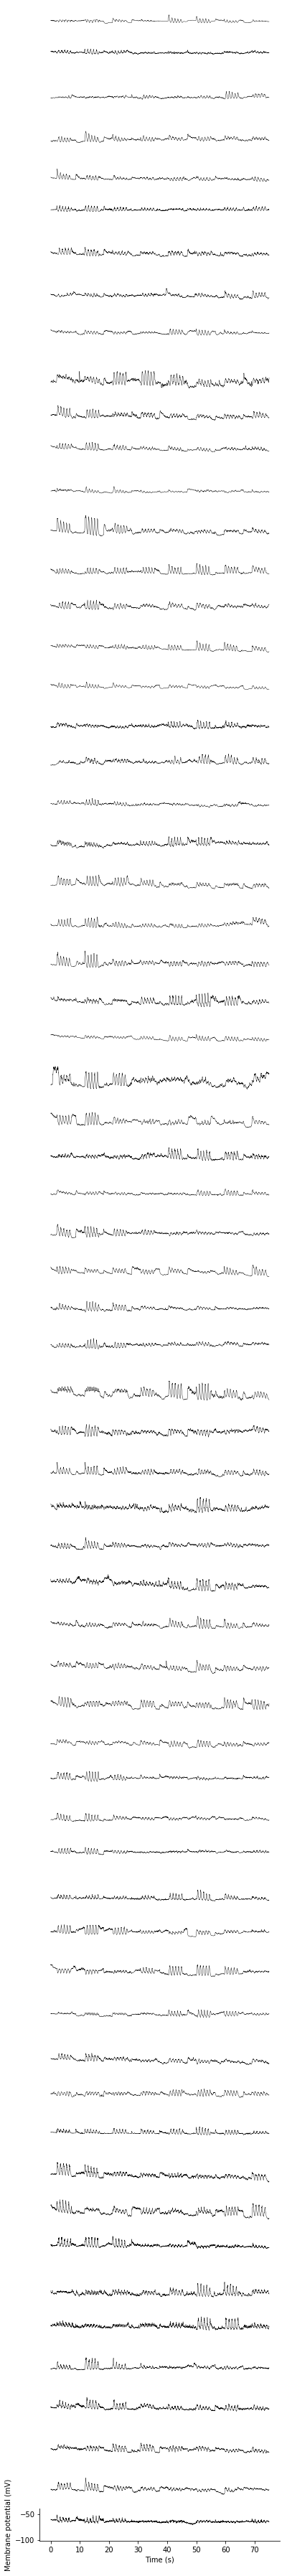

In [13]:
# Figure 1f:
fig, ax = plt.subplots(len(df_full_mean.cell.unique()),1 , figsize=(6, len(df_full_mean.cell.unique())), sharex=True, sharey=True)

for idx, c in enumerate(df_full_mean.cell.unique()):
        ax[idx].plot(df_full_mean.query("cell == @c").full_time.values[::4],
                     df_full_mean.query("cell == @c").voltage.values[::4],
                     c='k', alpha=1.0, linewidth=0.4)
        ax[idx].axis('off')

ax[-1].axis('on')
ax[-1].spines['right'].set_visible(False); ax[-1].spines['top'].set_visible(False)
ax[-1].set_ylabel('Membrane potential (mV)')
ax[-1].set_xlabel('Time (s)');
#plt.savefig('fig1f.pdf');

In [11]:
# Figure 1g (left): 
# Analyse directional tuning:

# Add new experiments:
gr_readout = pd.DataFrame()
for c in tqdm(df_mean.cell.unique()):
    for d in df_mean.query("cell == @c").deg.unique():
        #amp, mean = fitsig(df_mean.query("cell == @c and deg == @d and motion == True"), freq=1, plot=False)
        df = pd.DataFrame()
        df['cell'] = [c] # cell
        df['deg'] = [d]  # direction (°)
        df['rad'] = df['deg'] * np.pi/180.0 # direction (rad)
        df['delta'] = df_mean.query("cell == @c and deg == @d and motion == True").voltage.max() - df_mean.query("cell == @c and deg == @d and motion == False").voltage.mean()
        gr_readout = gr_readout.append(df)

100%|██████████| 65/65 [01:38<00:00,  1.51s/it]


In [12]:
# Calculate individual sub-vectors based on readout in the presence of motion:
# Choose readout:
ro = 'delta'

df_readout_a = pd.DataFrame()
for c in gr_readout.cell.unique():
    df_vec = gr_readout.query("cell == @c").reset_index()
    
    x = []
    y = []
    for i in df_vec.index:
        x.append(np.around((df_vec.loc[i, ro] * np.cos(df_vec.loc[i, 'rad'])), decimals=5))
        y.append(np.around((df_vec.loc[i, ro] * np.sin(df_vec.loc[i, 'rad'])), decimals=5))
    df_vec['x'] = x
    df_vec['y'] = y
    
    # Calculate individual vectors and vector sum:
    res_vec_x = df_vec['x'].sum()                       # resulting vector x
    res_vec_y = df_vec['y'].sum()                       # resulting vector y
    res_vec_mag = np.sqrt(res_vec_x**2 + res_vec_y**2)  # resulting vector magnitude (absolute value)
    
    if res_vec_x >= 0 and res_vec_y >= 0:
        res_vec_rad = np.arctan(res_vec_y/res_vec_x)
    elif res_vec_x < 0 and res_vec_y >= 0:
        res_vec_rad = np.pi + np.arctan(res_vec_y/res_vec_x)
    elif res_vec_x < 0 and res_vec_y < 0:
        res_vec_rad = np.pi + np.arctan(res_vec_y/res_vec_x)
    elif res_vec_x >= 0 and res_vec_y < 0:
        res_vec_rad = 2*np.pi + np.arctan(res_vec_y/res_vec_x)
    else:
        print('Error')
    
    res_vec_deg = res_vec_rad*180/np.pi
    #print(c, 'PD (deg) =', np.around(res_vec_deg))

    # Alignment based on vector sum:
    df_a = gr_readout.query("cell == @c")

    if 22.5*np.pi/180 <= res_vec_rad <= 67.5*np.pi/180 and res_vec_x > 0:
        PD = 45
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [315, 0, 45, 90, 135, 180, 225, 270], inplace=True)
    elif 67.5*np.pi/180 <= res_vec_rad <= 112.5*np.pi/180 and res_vec_y > 0:
        PD = 90
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [270, 315, 0, 45, 90, 135, 180, 225], inplace=True)
    elif 112.5*np.pi/180 <= res_vec_rad <= 157.5*np.pi/180 and res_vec_x < 0: 
        PD = 135
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [225, 270, 315, 0, 45, 90, 135, 180], inplace=True)
    elif 157.5*np.pi/180 <= res_vec_rad <= 202.5*np.pi/180 and res_vec_x < 0: 
        PD = 180
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [180, 225, 270, 315, 0, 45, 90, 135], inplace=True)
    elif 202.5*np.pi/180 <= res_vec_rad <= 247.5*np.pi/180 and res_vec_x < 0: 
        PD = 225
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [135, 180, 225, 270, 315, 0, 45, 90], inplace=True)
    elif 247.5*np.pi/180 <= res_vec_rad <= 292.5*np.pi/180 and res_vec_y < 0: 
        PD = 270
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [90, 135, 180, 225, 270, 315, 0, 45], inplace=True)
    elif 292.5*np.pi/180 <= res_vec_rad <= 337.5*np.pi/180 and res_vec_y < 0: 
        PD = 315
        df_a['deg'].replace([0, 45, 90, 135, 180, 225, 270, 315], [45, 90, 135, 180, 225, 270, 315, 0], inplace=True)
    else: 
        PD = 0
    
    #print('Original PD: {}°'.format(PD),'now aligned to 0°')
    
    df_a.sort_values(by=['deg'], inplace=True)
    df_a['rad'] = df_a['deg']*np.pi/180     # adjust the radians!
    df_readout_a = df_readout_a.append(df_a)

df_readout_a.head()

,cell,deg,rad,delta
0,20190903_T4-1,0.0,0.000000,12.132394
0,20190903_T4-1,45.0,0.785398,2.114753
0,20190903_T4-1,90.0,1.570796,8.875503
0,20190903_T4-1,135.0,2.356194,2.570294
0,20190903_T4-1,180.0,3.141593,1.967019


(n = 65 cells)


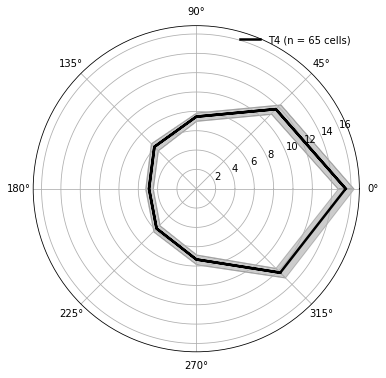

In [13]:
# Figure 1g (left):
# Create polar plots:
df_plot = df_readout_a.groupby(['deg', 'rad']).mean().reset_index()
df_plot_sem = df_readout_a.groupby(['deg', 'rad']).sem().reset_index()
df_plot, df_plot_sem  = df_plot.append(df_plot), df_plot_sem.append(df_plot_sem)

displaySEM = True

fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw=dict(polar=True), sharey=True)

ax.plot(df_plot.rad, 
        df_plot[ro], 
        color='k', linewidth=2.5, label="T4 (n = {} cells)".format(len(df_readout_a.cell.unique())))
if displaySEM == True:
    ax.fill_between(df_plot.rad,
                    df_plot[ro]-df_plot_sem[ro],
                    df_plot[ro]+df_plot_sem[ro], alpha=0.2, color='k')

print("(n = {} cells)".format(len(df_readout_a.cell.unique())))
ax.legend(frameon=False);
#plt.savefig('fig1g_left.pdf')

100%|██████████| 28/28 [01:37<00:00,  3.47s/it]


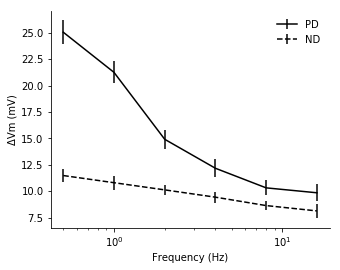

In [10]:
# Figure 1g (right):
data = pd.read_csv('fig1g_grating.csv', index_col=None)
data.head()

df_freq_tuning = pd.DataFrame()
for c in tqdm(data.cell.unique()[1:]): # [1:] excludes LED trace
    for d in data.query("cell == @c").dir.unique():
        for v in data.query("cell == @c and dir == @d").vel.unique():
            df = pd.DataFrame()
            df['cell'] = [c]
            df['dir'] = [d]
            df['delta'] = data.query("cell == @c and dir == @d and vel == @v").voltage.max() - data.query("cell == @c and dir == @d and vel == @v").voltage.min()
            df['freq'] = [v/30]
            df_freq_tuning = df_freq_tuning.append(df)
            
# Plot:
df_plot = df_freq_tuning.groupby(['dir', 'freq']).mean().reset_index()
df_plot_sem = df_freq_tuning.groupby(['dir', 'freq']).sem().reset_index()

fig, ax = plt.subplots(1, figsize=(5,4))
ls = ['-', '--']
for idx, d in enumerate(['PD', 'ND']): 
    ax.errorbar(df_plot.query("dir == @d").freq, df_plot.query("dir == @d")['delta'],
            yerr=df_plot_sem.query("dir == @d")['delta'], c='k', label=d, linestyle = ls[idx])
ax.set(xscale='log')
ax.legend(frameon=False);
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
ax.set_ylabel('ΔVm (mV)')
ax.set_xlabel('Frequency (Hz)');
#plt.savefig('fig1g_right.pdf');